# 1.数据读取与清洗

In [2]:
import pandas as pd
df = pd.read_pickle('/Users/yang./Desktop/测试数据-2020至今.pk')
df = df.dropna()
df

close      free_mkt   industry  status
trade_dt   code                                                 
2020-01-02 000001.SZ  1841.6882  1.451008e+11  801780.SI       0
           000002.SZ  4832.2920  1.976077e+11  801180.SI       0
           000004.SZ    90.7460  1.190862e+09  801150.SI       0
           000005.SZ    29.1003  2.592888e+09  801160.SI       0
           000006.SZ   191.3002  4.656473e+09  801180.SI       0
...                         ...           ...        ...     ...
2025-07-31 688799.SH    84.7347  4.446411e+09  801150.SI       0
           688800.SH    99.1180  7.097760e+09  801080.SI       0
           688819.SH    30.1375  3.717844e+09  801730.SI       0
           688981.SH    89.5000  1.511312e+11  801080.SI       0
           689009.SH    62.0949  3.241894e+10  801880.SI       0

[5974269 rows x 4 columns]

# 2.因子构建

In [3]:
import numpy as np
#构造动量因子、反转因子、规模因子、波动率因子
df = df.sort_values(['code', 'trade_dt'])
df['return'] = df.groupby('code')['close'].pct_change()
df['momentum_20'] = df.groupby('code')['close'].pct_change(20)
df['reversal_5'] = -df.groupby('code')['close'].pct_change(5)
df['size'] = -np.log(df['free_mkt'])
df['volatility_20'] = -df.groupby('code')['return'].rolling(20).std().reset_index(level=0, drop=True)
df

/Users/yang./conda_envs/quant/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/yang./conda_envs/quant/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,,close,free_mkt,industry,status,return,momentum_20,reversal_5,size,volatility_20
trade_dt,code,,,,,,,,,
2020-01-02,000001.SZ,1841.6882,1.451008e+11,801780.SI,0,NaN,NaN,NaN,-25.700694,NaN
2020-01-03,000001.SZ,1875.5308,1.477671e+11,801780.SI,0,0.018376,NaN,NaN,-25.718903,NaN
2020-01-06,000001.SZ,1863.5221,1.468210e+11,801780.SI,0,-0.006403,NaN,NaN,-25.712480,NaN
2020-01-07,000001.SZ,1872.2557,1.475091e+11,801780.SI,0,0.004687,NaN,NaN,-25.717156,NaN
2020-01-08,000001.SZ,1818.7627,1.432945e+11,801780.SI,0,-0.028571,NaN,NaN,-25.688168,NaN
...,...,...,...,...,...,...,...,...,...,...
2025-07-25,689009.SH,60.5866,3.163150e+10,801880.SI,0,-0.002534,0.017576,-0.008195,-24.177419,-0.017147
2025-07-28,689009.SH,60.7302,3.170649e+10,801880.SI,0,0.002370,0.000338,-0.020516,-24.179787,-0.016585
2025-07-29,689009.SH,60.1044,3.137973e+10,801880.SI,0,-0.010305,-0.009301,-0.007569,-24.169428,-0.016749


# 3.因子预处理

In [4]:
#因子去极值、标准化
def wash_factor(df,factor):
    results = []
    for date,group in df.groupby('trade_dt'):
        temp = group.copy()
        lower = temp[factor].quantile(0.05)
        upper = temp[factor].quantile(0.95)
        temp[factor] = temp[factor].clip(lower,upper)
        temp[factor] = (temp[factor] - temp[factor].mean()) / temp[factor].std()
        results.append(temp)
    df_clean = pd.concat(results)
    return df_clean

In [5]:
dp = df.copy()
factors = ['momentum_20','reversal_5','size','volatility_20']
for factor in factors:
    dp = wash_factor(dp,factor)
dp

close      free_mkt   industry  status    return  \
trade_dt   code                                                              
2020-01-02 000001.SZ  1841.6882  1.451008e+11  801780.SI       0       NaN   
           000002.SZ  4832.2920  1.976077e+11  801180.SI       0       NaN   
           000004.SZ    90.7460  1.190862e+09  801150.SI       0       NaN   
           000005.SZ    29.1003  2.592888e+09  801160.SI       0       NaN   
           000006.SZ   191.3002  4.656473e+09  801180.SI       0       NaN   
...                         ...           ...        ...     ...       ...   
2025-07-31 688799.SH    84.7347  4.446411e+09  801150.SI       0  0.029791   
           688800.SH    99.1180  7.097760e+09  801080.SI       0  0.062661   
           688819.SH    30.1375  3.717844e+09  801730.SI       0 -0.024771   
           688981.SH    89.5000  1.511312e+11  801080.SI       0 -0.009517   
           689009.SH    62.0949  3.241894e+10  801880.SI       0 -0.010463   

                      momentum_20  reversal_5      size  volatility_20  
trade_dt   code                                                         
2020-01-02 000001.SZ          NaN         NaN -2.203304            NaN  
           000002.SZ          NaN         NaN -2.203304            NaN  
           000004.SZ          NaN         NaN  0.900800            NaN  
           000005.SZ          NaN         NaN  0.053948            NaN  
           000006.SZ          NaN         NaN -0.583275            NaN  
...                           ...         ...       ...            ...  
2025-07-31 688799.SH     1.707159   -0.861448 -0.154242      -2.435286  
           688800.SH     1.844061   -2.269437 -0.654289      -0.855745  
           688819.SH    -0.303282    0.678233  0.037095       0.814922  
           688981.SH     0.007970    0.338984 -2.116052       0.696310  
           689009.SH    -0.682285   -0.807170 -2.116052       0.471020  

[5974269 rows x 9 columns]

In [6]:
#动量因子、反转因子、波动率因子对市值、行业中性化
import statsmodels.api as sm
def neutralize_factor(df,factor):
    results = []
    for date,group in df.groupby('trade_dt'):
        dp = group[group['free_mkt'] > 0].copy()
        #先将市值取对数、去极值、标准化
        dp['log_free_mkt'] = np.log(dp['free_mkt'])
        lower = dp['log_free_mkt'].quantile(0.05)
        upper = dp['log_free_mkt'].quantile(0.95)
        dp['log_free_mkt'] = dp['log_free_mkt'].clip(lower,upper)
        dp['log_free_mkt'] = (dp['log_free_mkt'] - dp['log_free_mkt'].mean()) / dp['log_free_mkt'].std()
        industry_dummies = pd.get_dummies(dp['industry'],dtype=float)
        #市值对行业中性化
        x_mkt = industry_dummies
        x_mkt = sm.add_constant(x_mkt)
        y_mkt = dp['log_free_mkt']
        valid_mkt = y_mkt.notna() & x_mkt.notna().all(axis=1)
        y_mkt = y_mkt[valid_mkt]
        x_mkt = x_mkt[valid_mkt]
        if len(y_mkt) < 10:
            continue
        model_mkt = sm.OLS(y_mkt,x_mkt).fit()
        dp.loc[valid_mkt,'mkt_neutral'] = model_mkt.resid
        #因子对市值、行业中性化
        x_factor = pd.concat([dp['mkt_neutral'],industry_dummies],axis=1)
        x_factor = sm.add_constant(x_factor)
        y_factor = dp[factor]
        valid_factor = y_factor.notna() & x_factor.notna().all(axis=1)
        y_factor = y_factor[valid_factor]
        x_factor = x_factor[valid_factor]
        if len(y_factor) < 10:
            continue
        model_factor = sm.OLS(y_factor,x_factor).fit()
        dp.loc[valid_factor,f"{factor}_neutral"] = model_factor.resid
        results.append(dp)
    df_resuls = pd.concat(results).sort_index()
    df[f"{factor}_neutral"] = df_resuls[f"{factor}_neutral"]
    return df

In [7]:
dj = dp.copy()
factor1 = ['momentum_20','reversal_5','volatility_20']
for factor in factor1:
    dj = neutralize_factor(dj,factor)
dj

close      free_mkt   industry  status    return  \
trade_dt   code                                                              
2020-01-02 000001.SZ  1841.6882  1.451008e+11  801780.SI       0       NaN   
           000002.SZ  4832.2920  1.976077e+11  801180.SI       0       NaN   
           000004.SZ    90.7460  1.190862e+09  801150.SI       0       NaN   
           000005.SZ    29.1003  2.592888e+09  801160.SI       0       NaN   
           000006.SZ   191.3002  4.656473e+09  801180.SI       0       NaN   
...                         ...           ...        ...     ...       ...   
2025-07-31 688799.SH    84.7347  4.446411e+09  801150.SI       0  0.029791   
           688800.SH    99.1180  7.097760e+09  801080.SI       0  0.062661   
           688819.SH    30.1375  3.717844e+09  801730.SI       0 -0.024771   
           688981.SH    89.5000  1.511312e+11  801080.SI       0 -0.009517   
           689009.SH    62.0949  3.241894e+10  801880.SI       0 -0.010463   

                      momentum_20  reversal_5      size  volatility_20  \
trade_dt   code                                                          
2020-01-02 000001.SZ          NaN         NaN -2.203304            NaN   
           000002.SZ          NaN         NaN -2.203304            NaN   
           000004.SZ          NaN         NaN  0.900800            NaN   
           000005.SZ          NaN         NaN  0.053948            NaN   
           000006.SZ          NaN         NaN -0.583275            NaN   
...                           ...         ...       ...            ...   
2025-07-31 688799.SH     1.707159   -0.861448 -0.154242      -2.435286   
           688800.SH     1.844061   -2.269437 -0.654289      -0.855745   
           688819.SH    -0.303282    0.678233  0.037095       0.814922   
           688981.SH     0.007970    0.338984 -2.116052       0.696310   
           689009.SH    -0.682285   -0.807170 -2.116052       0.471020   

                      momentum_20_neutral  reversal_5_neutral  \
trade_dt   code                                                 
2020-01-02 000001.SZ                  NaN                 NaN   
           000002.SZ                  NaN                 NaN   
           000004.SZ                  NaN                 NaN   
           000005.SZ                  NaN                 NaN   
           000006.SZ                  NaN                 NaN   
...                                   ...                 ...   
2025-07-31 688799.SH             0.983172           -0.199120   
           688800.SH             1.796992           -1.721122   
           688819.SH            -0.137848            0.372907   
           688981.SH            -0.209863            0.806063   
           689009.SH            -0.767479           -1.041056   

                      volatility_20_neutral  
trade_dt   code                              
2020-01-02 000001.SZ                    NaN  
           000002.SZ                    NaN  
           000004.SZ                    NaN  
           000005.SZ                    NaN  
           000006.SZ                    NaN  
...                                     ...  
2025-07-31 688799.SH              -2.244073  
           688800.SH              -0.878644  
           688819.SH               0.921253  
           688981.SH               0.679857  
           689009.SH               0.334091  

[5974269 rows x 12 columns]

In [8]:
#单独将规模因子对行业中性化
for date,group in dj.groupby('trade_dt'):
    industry_dummies = pd.get_dummies(group['industry'],dtype=float)
    y_factor = group['size']
    x_factor = industry_dummies
    x_factor = sm.add_constant(x_factor)
    valid_factor = y_factor.notna() & x_factor.notna().all(axis=1)
    y_factor = y_factor[valid_factor]
    x_factor = x_factor[valid_factor]
    model_factor = sm.OLS(y_factor,x_factor).fit()
    dj.loc[group.index[valid_factor], 'neutral_size'] = model_factor.resid
#将中性化后的因子再次标准化
neutral_factors = ['momentum_20_neutral','reversal_5_neutral','neutral_size','volatility_20_neutral']
for factor in neutral_factors:
    dj[factor] = dj.groupby('trade_dt')[factor].transform(
        lambda x: (x - x.mean()) / x.std()
    )
dj

close      free_mkt   industry  status    return  \
trade_dt   code                                                              
2020-01-02 000001.SZ  1841.6882  1.451008e+11  801780.SI       0       NaN   
           000002.SZ  4832.2920  1.976077e+11  801180.SI       0       NaN   
           000004.SZ    90.7460  1.190862e+09  801150.SI       0       NaN   
           000005.SZ    29.1003  2.592888e+09  801160.SI       0       NaN   
           000006.SZ   191.3002  4.656473e+09  801180.SI       0       NaN   
...                         ...           ...        ...     ...       ...   
2025-07-31 688799.SH    84.7347  4.446411e+09  801150.SI       0  0.029791   
           688800.SH    99.1180  7.097760e+09  801080.SI       0  0.062661   
           688819.SH    30.1375  3.717844e+09  801730.SI       0 -0.024771   
           688981.SH    89.5000  1.511312e+11  801080.SI       0 -0.009517   
           689009.SH    62.0949  3.241894e+10  801880.SI       0 -0.010463   

                      momentum_20  reversal_5      size  volatility_20  \
trade_dt   code                                                          
2020-01-02 000001.SZ          NaN         NaN -2.203304            NaN   
           000002.SZ          NaN         NaN -2.203304            NaN   
           000004.SZ          NaN         NaN  0.900800            NaN   
           000005.SZ          NaN         NaN  0.053948            NaN   
           000006.SZ          NaN         NaN -0.583275            NaN   
...                           ...         ...       ...            ...   
2025-07-31 688799.SH     1.707159   -0.861448 -0.154242      -2.435286   
           688800.SH     1.844061   -2.269437 -0.654289      -0.855745   
           688819.SH    -0.303282    0.678233  0.037095       0.814922   
           688981.SH     0.007970    0.338984 -2.116052       0.696310   
           689009.SH    -0.682285   -0.807170 -2.116052       0.471020   

                      momentum_20_neutral  reversal_5_neutral  \
trade_dt   code                                                 
2020-01-02 000001.SZ                  NaN                 NaN   
           000002.SZ                  NaN                 NaN   
           000004.SZ                  NaN                 NaN   
           000005.SZ                  NaN                 NaN   
           000006.SZ                  NaN                 NaN   
...                                   ...                 ...   
2025-07-31 688799.SH             1.036150           -0.217072   
           688800.SH             1.893824           -1.876286   
           688819.SH            -0.145276            0.406526   
           688981.SH            -0.221171            0.878732   
           689009.SH            -0.808835           -1.134910   

                      volatility_20_neutral  neutral_size  
trade_dt   code                                            
2020-01-02 000001.SZ                    NaN     -0.589900  
           000002.SZ                    NaN     -2.111810  
           000004.SZ                    NaN      1.174952  
           000005.SZ                    NaN      0.027251  
           000006.SZ                    NaN     -0.370970  
...                                     ...           ...  
2025-07-31 688799.SH              -2.311035      0.025134  
           688800.SH              -0.904862     -0.379813  
           688819.SH               0.948743      0.099368  
           688981.SH               0.700144     -1.950743  
           689009.SH               0.344060     -2.309441  

[5974269 rows x 13 columns]

# 4.单因子检验

In [9]:
#计算每个因子的rank ic
dj['future'] = dj.groupby('code')['close'].shift(-20) / dj['close'] - 1
dates = sorted(dj.index.get_level_values('trade_dt').unique())
valid_dates = dates[30:-20]
def rank_ic(dp,factor):
    ic_results = []
    for date,group in dp.groupby('trade_dt'):
        if date not in valid_dates:
            continue
        ic = group[factor].corr(group['future'],method='spearman')
        ic_results.append({
            'date':date,
            'ic':ic
        })
    ic_results = pd.DataFrame(ic_results)
    ic_results['date'] = pd.to_datetime(ic_results['date'])
    ic_results = ic_results.set_index('date')
    return ic_results

In [10]:
ic_table = pd.DataFrame()

for factor in neutral_factors:
    result = rank_ic(dj, factor)
    ic_table[factor] = result['ic']
ic_table

,momentum_20_neutral,reversal_5_neutral,neutral_size,volatility_20_neutral
date,,,,
2020-02-21,-0.038115,0.029795,0.205440,0.225665
2020-02-24,-0.119798,0.083249,0.212585,0.297543
2020-02-25,-0.203938,0.089477,0.232399,0.346151
2020-02-26,-0.116059,-0.013367,0.214373,0.287707
2020-02-27,-0.085063,-0.067408,0.213228,0.273182
...,...,...,...,...
2025-06-27,-0.067870,-0.023090,-0.011756,0.127720
2025-06-30,-0.023479,-0.055075,0.010228,0.135665
2025-07-01,-0.021564,-0.013192,-0.026904,0.128991


In [11]:
for factor in neutral_factors:
    print(f"{factor}_ic>0:{(ic_table[factor]>0).mean()}")
    print(f"{factor}_ic_mean:{ic_table[factor].mean()}") 
    print(f"{factor}_ic_std:{ic_table[factor].std()}")
    print(f"{factor}_ic_icir:{ic_table[factor].mean() / ic_table[factor].std()}") 

momentum_20_neutral_ic>0:0.28823981552651806
momentum_20_neutral_ic_mean:-0.05620448865182171
momentum_20_neutral_ic_std:0.09799660421645973
momentum_20_neutral_ic_icir:-0.5735350638035831
reversal_5_neutral_ic>0:0.6179861644888547
reversal_5_neutral_ic_mean:0.029746982674829676
reversal_5_neutral_ic_std:0.0851841477967906
reversal_5_neutral_ic_icir:0.3492079623287659
neutral_size_ic>0:0.6740968485780169
neutral_size_ic_mean:0.04834151535068402
neutral_size_ic_std:0.16986772177141893
neutral_size_ic_icir:0.284583291319668
volatility_20_neutral_ic>0:0.7909300538047656
volatility_20_neutral_ic_mean:0.09577403010370332
volatility_20_neutral_ic_std:0.12528473850574928
volatility_20_neutral_ic_icir:0.7644508919919906


In [12]:
summary = pd.DataFrame(index=ic_table.columns,
                       columns=['IC_mean', 'IC_std', 'ICIR', 'IC_positive'])
for factor in ic_table.columns:
    ic_series = ic_table[factor].dropna()
    ic_mean = ic_series.mean()
    ic_std = ic_series.std()
    icir = ic_mean / ic_std
    ic_positive = (ic_series > 0).mean()
    summary.loc[factor] = [ic_mean, ic_std, icir, ic_positive]
summary

,IC_mean,IC_std,ICIR,IC_positive
momentum_20_neutral,-0.056204,0.097997,-0.573535,0.28824
reversal_5_neutral,0.029747,0.085184,0.349208,0.617986
neutral_size,0.048342,0.169868,0.284583,0.674097
volatility_20_neutral,0.095774,0.125285,0.764451,0.79093


# 5.因子相关性分析

In [14]:
factors123 = ['momentum_20_neutral','reversal_5_neutral','neutral_size','volatility_20_neutral']
avg_corr_matrix = (
    dj.groupby('trade_dt')[factors123]
      .corr()
      .groupby(level=1)
      .mean()
)
avg_corr_matrix

,momentum_20_neutral,reversal_5_neutral,neutral_size,volatility_20_neutral
momentum_20_neutral,1.000000,-0.449859,-0.000002,-0.299179
neutral_size,-0.000002,0.000001,1.000000,0.000003
reversal_5_neutral,-0.449859,1.000000,0.000001,0.061012
volatility_20_neutral,-0.299179,0.061012,0.000003,1.000000


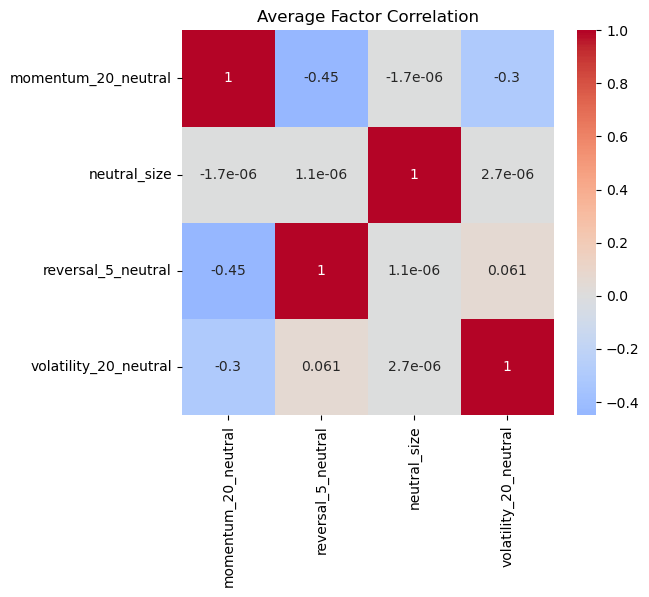

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(avg_corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Average Factor Correlation')
plt.show()

# 6.多因子模型构建

In [16]:
dj['momentum_adj'] = -dj['momentum_20_neutral']
dj['reversal_adj'] = dj['reversal_5_neutral']
dj['size_adj'] = dj['neutral_size']
dj['volatility_adj'] = dj['volatility_20_neutral']
dj['composite_factor'] = (dj['momentum_adj'] +dj['reversal_adj'] +dj['size_adj'] +dj['volatility_adj']) / 4

In [17]:
composite_factor_ic = []
for date,group in dj.groupby('trade_dt'):
    if date not in valid_dates:
        continue
    rank_ic = group['composite_factor'].corr(group['future'],method='spearman')
    composite_factor_ic.append({
        'date':date,
        'ic':rank_ic
    })
composite_factor_ic = pd.DataFrame(composite_factor_ic)
composite_factor_ic['date'] = pd.to_datetime(composite_factor_ic['date'])
composite_factor_ic = composite_factor_ic.set_index('date')
composite_factor_ic

,ic
date,
2020-02-21,0.228530
2020-02-24,0.298527
2020-02-25,0.356878
2020-02-26,0.263226
2020-02-27,0.221185
...,...
2025-06-27,0.085992
2025-06-30,0.075158
2025-07-01,0.075619


In [18]:
ic_series = composite_factor_ic['ic'].dropna()
ic_mean = ic_series.mean()
ic_std = ic_series.std()
icir = ic_mean / ic_std if ic_std != 0 else np.nan
ic_positive = (ic_series > 0).mean()
summary.loc['composite_factor'] = [
    ic_mean,
    ic_std,
    icir,
    ic_positive
]
summary

,IC_mean,IC_std,ICIR,IC_positive
momentum_20_neutral,-0.056204,0.097997,-0.573535,0.28824
reversal_5_neutral,0.029747,0.085184,0.349208,0.617986
neutral_size,0.048342,0.169868,0.284583,0.674097
volatility_20_neutral,0.095774,0.125285,0.764451,0.79093
composite_factor,0.10284,0.11943,0.861091,0.807071


# 7.分层回测

In [19]:
future_df = dj['future'].unstack()

In [20]:
composite_factor = dj['composite_factor'].unstack()

In [21]:
group_results = []
test_date = composite_factor.index[30:len(composite_factor)-20:20]
for date in test_date:
    factor = composite_factor.loc[date]
    future = future_df.loc[date]
    dl = pd.DataFrame({
        'factor':factor,
        'future':future
    }).dropna()
    dl['rank'] = dl['factor'].rank()
    dl['quantile'] = pd.qcut(dl['rank'],10,labels=False)
    group_return = dl.groupby('quantile')['future'].mean()
    group_return['date'] = date
    group_results.append(group_return)
group_results_df = pd.DataFrame(group_results)
group_results_df['date'] = pd.to_datetime(group_results_df['date'])
group_results_df = group_results_df.set_index('date')
group_results_df['long_short'] = group_results_df[9] - group_results_df[0]
group_results_df

quantile,0,1,2,3,4,5,6,7,8,9,long_short
date,,,,,,,,,,,
2020-02-21,-0.119691,-0.091899,-0.083204,-0.067193,-0.057526,-0.042045,-0.054029,-0.037385,-0.041412,-0.036601,0.083090
2020-03-20,0.001122,0.009601,0.009918,0.020340,0.013215,0.017159,0.026097,0.022317,0.019669,0.023822,0.022700
2020-04-20,-0.010882,-0.001637,0.004829,-0.000866,-0.010259,0.000255,-0.008866,-0.003258,-0.027800,-0.045410,-0.034528
2020-05-21,0.053543,0.063760,0.067457,0.061130,0.055285,0.052247,0.056291,0.066364,0.067597,0.074392,0.020849
2020-06-18,0.135310,0.122702,0.128717,0.150783,0.146983,0.137480,0.127446,0.129702,0.112596,0.095735,-0.039575
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,-0.088546,-0.059370,-0.040693,-0.021319,-0.022564,-0.007444,-0.000099,-0.000741,0.009604,0.003802,0.092348
2025-04-03,0.006791,0.001674,-0.004274,-0.004820,-0.009657,-0.006349,0.003831,0.009675,0.013734,0.003668,-0.003124
2025-05-07,0.028917,0.028721,0.036564,0.043144,0.032936,0.042919,0.045201,0.038521,0.047942,0.045850,0.016933


In [22]:
cum_group_return = (1 + group_results_df).cumprod()
cum_group_return

quantile,0,1,2,3,4,5,6,7,8,9,long_short
date,,,,,,,,,,,
2020-02-21,0.880309,0.908101,0.916796,0.932807,0.942474,0.957955,0.945971,0.962615,0.958588,0.963399,1.083090
2020-03-20,0.881297,0.916819,0.925889,0.951780,0.954929,0.974392,0.970659,0.984098,0.977443,0.986349,1.107676
2020-04-20,0.871706,0.915319,0.930360,0.950956,0.945132,0.974640,0.962053,0.980892,0.950270,0.941559,1.069430
2020-05-21,0.918380,0.973679,0.993119,1.009088,0.997384,1.025562,1.016209,1.045988,1.014505,1.011603,1.091726
2020-06-18,1.042647,1.093152,1.120951,1.161241,1.143983,1.166556,1.145720,1.181655,1.128734,1.108449,1.048521
...,...,...,...,...,...,...,...,...,...,...,...
2025-03-06,0.500444,0.983554,1.242452,1.406497,1.625325,1.727014,1.893702,2.189140,2.133832,1.873946,3.370823
2025-04-03,0.503843,0.985201,1.237142,1.399718,1.609629,1.716049,1.900956,2.210320,2.163138,1.880819,3.360294
2025-05-07,0.518413,1.013496,1.282377,1.460108,1.662643,1.789700,1.986882,2.295464,2.266842,1.967054,3.417194


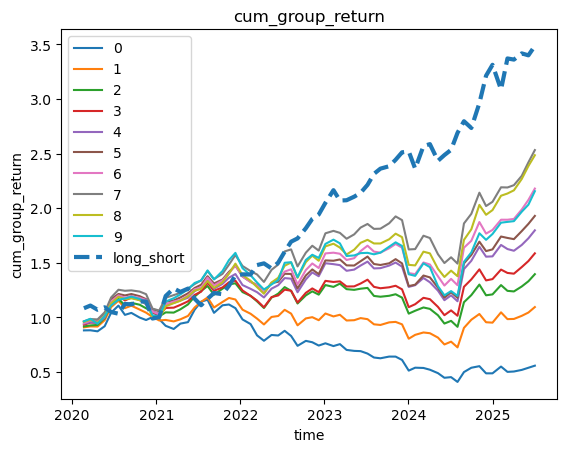

In [23]:
for columns in cum_group_return.columns:
    if columns == 'long_short':
        plt.plot(cum_group_return[columns],linestyle = '--',label = columns,linewidth = 3)
    else:
        plt.plot(cum_group_return[columns],label = columns)
plt.xlabel('time')
plt.ylabel('cum_group_return')
plt.title('cum_group_return')
plt.legend()
plt.savefig('composite_factor_quantile_backtest_result.png')
plt.show()

In [24]:
the_group_results = []
for columns in group_results_df.columns:
    cumprod = (1 + group_results_df[columns]).cumprod()
    cummax = cumprod.cummax()
    annual_return = cumprod.iloc[-1] ** (252 / (len(group_results_df[columns]) * 20)) - 1
    annual_volatility = group_results_df[columns].std() * (252/20) ** 0.5
    sharpe = group_results_df[columns].mean() / group_results_df[columns].std() * (252/20) ** 0.5
    drawdown = (cumprod - cummax) / cummax
    max_drawdown = drawdown.min()
    the_group_results.append({
        'group':columns,
        'annual_return':annual_return,
        'volatility':annual_volatility,
        'sharpe':sharpe,
        'max_drawdown':max_drawdown
    })
the_group_results_df = pd.DataFrame(the_group_results)
the_group_results_df = the_group_results_df.set_index('group')
the_group_results_df

,annual_return,volatility,sharpe,max_drawdown
group,,,,
0,-0.105630,0.243518,-0.337243,-0.648303
1,0.017282,0.214723,0.182933,-0.386558
2,0.065634,0.205027,0.408603,-0.303957
3,0.092030,0.209744,0.520393,-0.245761
4,0.118343,0.206966,0.640634,-0.240367
5,0.133614,0.210191,0.699148,-0.242594
6,0.160323,0.215670,0.796174,-0.227837
7,0.194029,0.214354,0.935969,-0.224669
8,0.189749,0.219022,0.904105,-0.224493


# 8.因子贡献分析-回归分析

In [25]:
import statsmodels.api as sm
ols_results = []
for date,group in dj.groupby('trade_dt'):
    if date not in valid_dates:
            continue
    y = group['future']
    x = group[['momentum_adj','reversal_adj','size_adj','volatility_adj']]
    x = sm.add_constant(x)
    valid_factor = y.notna() & x.notna().all(axis=1)
    y = y[valid_factor]
    x = x[valid_factor]
    if len(y) < 10:
        continue
    model = sm.OLS(y,x).fit()
    ols_results.append({
        'date': date,
        'momentum_beta': model.params['momentum_adj'],
        'momentum_t': model.tvalues['momentum_adj'],
        'momentum_p': model.pvalues['momentum_adj'],

        'reversal_beta': model.params['reversal_adj'],
        'reversal_t': model.tvalues['reversal_adj'],
        'reversal_p': model.pvalues['reversal_adj'],

        'size_beta': model.params['size_adj'],
        'size_t': model.tvalues['size_adj'],
        'size_p': model.pvalues['size_adj'],

        'volatility_beta': model.params['volatility_adj'],
        'volatility_t': model.tvalues['volatility_adj'],
        'volatility_p': model.pvalues['volatility_adj']
    })
ols_results_df = pd.DataFrame(ols_results)
ols_results_df['date'] = pd.to_datetime(ols_results_df['date'])
ols_results_df = ols_results_df.set_index('date')

In [26]:
Factors = ['momentum', 'reversal', 'size', 'volatility']
Summary = pd.DataFrame(
    columns=['beta_mean', 'beta>0', 't_mean', 'p<0.05'],
    index=Factors
)
for factor in Factors:
    beta_series = ols_results_df[f'{factor}_beta'].dropna()
    t_series = ols_results_df[f'{factor}_t'].dropna()
    p_series = ols_results_df[f'{factor}_p'].dropna()
    
    Summary.loc[factor, 'beta_mean'] = beta_series.mean()
    Summary.loc[factor, 'beta>0'] = (beta_series > 0).mean()
    Summary.loc[factor, 't_mean'] = t_series.abs().mean()
    Summary.loc[factor, 'p<0.05'] = (p_series < 0.05).mean()
Summary

,beta_mean,beta>0,t_mean,p<0.05
momentum,0.000319,0.458109,3.673586,0.638739
reversal,0.002312,0.592621,3.028632,0.589547
size,0.004204,0.667948,8.002528,0.864719
volatility,0.005501,0.667179,5.933847,0.777095


# 9.因子贡献分析-逐步剔除

In [76]:
from itertools import combinations

def evaluate_model(factor_list):
    temp_df = dj.copy()
    temp_df['composite'] = temp_df[factor_list].mean(axis=1)
    # 计算 IC
    ic_series = rank_ic(temp_df, 'composite')
    ic_mean = ic_series['ic'].mean()
    icir = ic_mean / ic_series['ic'].std()
    
    # 分层回测
    Composite = temp_df['composite'].unstack()
    group_results = []
    test_date = Composite.index[30:len(Composite)-20:20]
    for date in test_date:
        factor = Composite.loc[date]
        future = future_df.loc[date]
        dl = pd.DataFrame({
            'factor':factor,
            'future':future
        }).dropna()
        dl['rank'] = dl['factor'].rank()
        dl['quantile'] = pd.qcut(dl['rank'],10,labels=False)
        group_return = dl.groupby('quantile')['future'].mean()
        group_return['date'] = date
        group_results.append(group_return)
    group_results_df = pd.DataFrame(group_results)
    group_results_df['date'] = pd.to_datetime(group_results_df['date'])
    group_results_df = group_results_df.set_index('date')
    group_results_df['long_short'] = group_results_df[9] - group_results_df[0]
    sharpe = group_results_df['long_short'].mean() / group_results_df['long_short'].std() * (252/20) ** 0.5

    return ic_mean, icir, sharpe


evaluate_results = []
all_factors = ['momentum_adj','reversal_adj','size_adj','volatility_adj']
full_factors = all_factors
evaluate_results.append(('Full', *evaluate_model(full_factors)))

for factor in all_factors:
    remaining = [f for f in all_factors if f != factor]
    evaluate_results.append((f'Remove_{factor}', *evaluate_model(remaining)))

evaluate_results_df = pd.DataFrame(evaluate_results, columns=['Model', 'IC_mean', 'ICIR', 'Sharpe'])
evaluate_results_df = evaluate_results_df.set_index('Model')
evaluate_results_df

,IC_mean,ICIR,Sharpe
Model,,,
Full,0.101672,0.853277,1.468456
Remove_momentum_adj,0.105690,0.823751,1.367550
Remove_reversal_adj,0.109400,0.845396,1.459498
Remove_size_adj,0.081267,0.876588,1.492905
Remove_volatility_adj,0.074779,0.579420,1.101619


In [77]:
icir = {
    'momentum': -0.57,
    'reversal': 0.35,
    'size': 0.28,
    'volatility': 0.76
}

total = sum(abs(v) for v in icir.values())
weights = {k: abs(v)/total for k, v in icir.items()}
print(weights)

{'momentum': 0.29081632653061223, 'reversal': 0.17857142857142858, 'size': 0.14285714285714288, 'volatility': 0.3877551020408163}
